# Post-Treatement of the data
The aim of this notebook is to import the different simulations, and compute the different indices of quality as well as the volume.  
The indices we calculate are the following for the synthetic :
1. Sum of the error 
2. Absolute sum of the error
3. Normalized Sum
4. Standard Deviation
5. Mean

For the real data, we just compute the volume.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages
exec(open('../functions/03_indice_calculation_functions.py').read())


## Simulation output

In [2]:
def indice_dataframe(simu_sets_paths):

    all_output = []
    real_vol   = []
    type_sim   = ['MPS','GRF']
    simulation_name = os.listdir(simu_sets_paths)
    for name in simulation_name:

        with open(simu_sets_paths+name,'rb') as file:
            trueMNT, trend_cut, simu_sets, mask_box_ti, position = pickle.load(file)

        trueMNT += trend_cut
        for i, simus in enumerate(simu_sets):        
            if np.all(simus != None):

                simus = np.add(trend_cut, simus)

                indice_out = indice_calculationV(trueMNT, simus, 'mps')

                all_output.append([name[:-12], type_sim[i]]+indice_out)


    results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','Real Volume'])
    
    return results_frame

In [68]:
path_sets = '../simulation_outputs_with_trend_24/'
list_sets = sorted(os.listdir(path_sets))[:]
list_sets

['simulation_set_00',
 'simulation_set_01',
 'simulation_set_02',
 'simulation_set_03',
 'simulation_set_04',
 'simulation_set_05',
 'simulation_set_06',
 'simulation_set_07',
 'simulation_set_08',
 'simulation_set_09',
 'simulation_set_10',
 'simulation_set_11']

In [69]:
all_results = []
for name_set in list_sets:
    all_results.append(indice_dataframe(path_sets+name_set+'/'))

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:155: RuntimeWarning: divide by zero encountered in true_divide
/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:155: RuntimeWarning: invalid value encountered in true_divide


In [62]:
all_results[0]

,Sim_name,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,Real Volume
0,simulation_realisation0.p,MPS,-1.154186,4.019877,1.358863,"[[2291.521443684896, 2291.864247639974, 2292.4...","[[0.8887216174465071, 0.918319098202181, 1.016...","[514475.357666017, 512924.67456054926, 512609....",500000.0
1,simulation_realisation8.p,MPS,1.745637,4.292619,1.581564,"[[2428.75249226888, 2428.2919921874995, 2427.9...","[[0.4737598470587765, 0.0, 0.44606631828012777...","[477342.52636718913, 486447.4787597676, 489031...",500000.0
2,simulation_realisation4.p,MPS,1.541887,4.760602,1.732327,"[[2251.383371988932, 2251.0081583658853, 2250....","[[1.0175931163792096, 1.2056800804485732, 1.19...","[486153.51684570475, 468138.44091797044, 45725...",500000.0
3,simulation_realisation3.p,MPS,-1.201440,3.806726,1.772777,"[[2593.9683430989585, 2593.6343282063804, 2593...","[[1.1524901359957456, 1.2954283040534824, 0.70...","[502000.27026367345, 504377.17407226807, 51073...",500000.0
4,simulation_realisation9.p,MPS,0.337516,3.215502,1.533494,"[[2232.1684061686196, 2231.7709147135415, 2231...","[[0.8069055443322694, 0.7692478408942156, 0.81...","[495572.10937500204, 505417.0144042984, 489473...",500000.0
5,simulation_realisation10.p,MPS,-1.008612,3.590801,1.631923,"[[2306.721181233724, 2306.152333577474, 2305.3...","[[1.1283167704213888, 0.9922970125109326, 0.87...","[500100.6447753925, 513438.896728517, 523826.4...",500000.0
6,simulation_realisation11.p,MPS,-0.430337,4.784414,1.511571,"[[2591.605265299479, 2591.361582438151, 2590.7...","[[0.9491469526587974, 0.9161413101891976, 1.00...","[520007.5319824228, 477095.2353515648, 476455....",500000.0
7,simulation_realisation6.p,MPS,-2.713793,5.310074,2.470955,"[[2431.4176635742188, 2430.7575174967446, 2430...","[[1.5574279179873554, 1.3548031105682554, 1.61...","[524356.9970703144, 516645.63842773624, 535736...",500000.0
8,simulation_realisation1.p,MPS,-0.833051,3.561987,1.335938,"[[2524.1210021972656, 2523.9891560872397, 2524...","[[0.5907992474818115, 1.0880390614241984, 1.09...","[511801.26953125244, 513240.4682617207, 512634...",500000.0
9,simulation_realisation7.p,MPS,-0.815491,5.305811,1.227259,"[[2298.5289001464844, 2297.9102783203125, 2296...","[[0.900018353883651, 1.0816813889125354, 1.382...","[516986.56030273624, 520478.1938476588, 528874...",500000.0


|        | n  | t     | f   |
|--------|----|-------|-----|
| Set 00 | 6  | 0.01  | 0.1 |
| Set 01 | 6  | 0.01  | 0.5 |
| Set 02 | 6  | 0.005 | 0.1 |
| Set 03 | 6  | 0.005 | 0.5 |
| Set 04 | 12 | 0.01  | 0.1 |
| Set 05 | 12 | 0.01  | 0.5 |
| Set 06 | 12 | 0.005 | 0.1 |
| Set 07 | 12 | 0.005 | 0.5 |
| Set 08 | 24 | 0.01  | 0.1 |
| Set 09 | 24 | 0.01  | 0.5 |
| Set 10 | 24 | 0.005 | 0.1 |
| Set 11 | 24 | 0.005 | 0.5 |

In [66]:
path_sets = '../simulation_outputs_without_trend/'
list_sets = sorted(os.listdir(path_sets))[:]
list_sets

['simulation_set_0',
 'simulation_set_1',
 'simulation_set_2',
 'simulation_set_3']

In [67]:
all_results_2 = []
for name_set in list_sets:
    all_results_2.append(indice_dataframe(path_sets+name_set+'/'))

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:155: RuntimeWarning: divide by zero encountered in true_divide


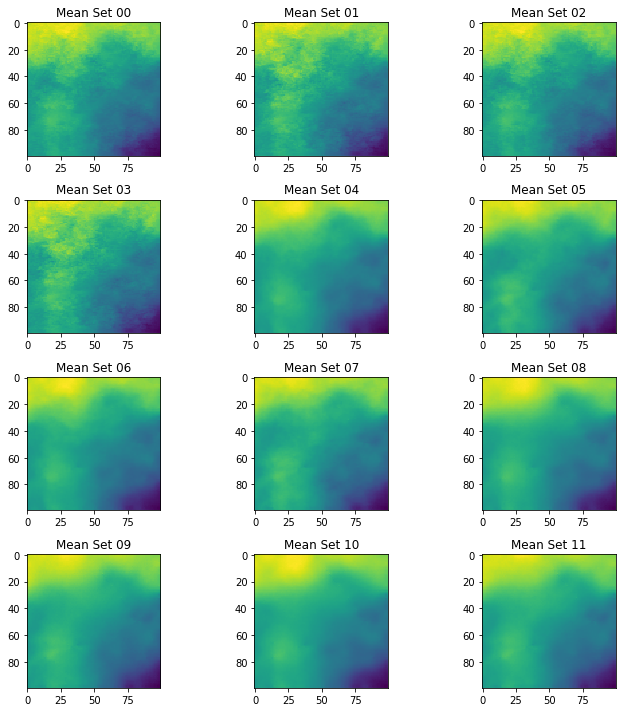

In [63]:
#Effect of the deesse parameter on the mean simulation for the test case 1
fig = plt.subplots(4,3,figsize=(10,10))
for i in range(len(all_results)):
    plt.subplot(4,3,i+1)
    plt.imshow(all_results[i].Mean[0])
    plt.title('Mean Set {}'.format(str(i).zfill(2)))

plt.tight_layout()
plt.show()

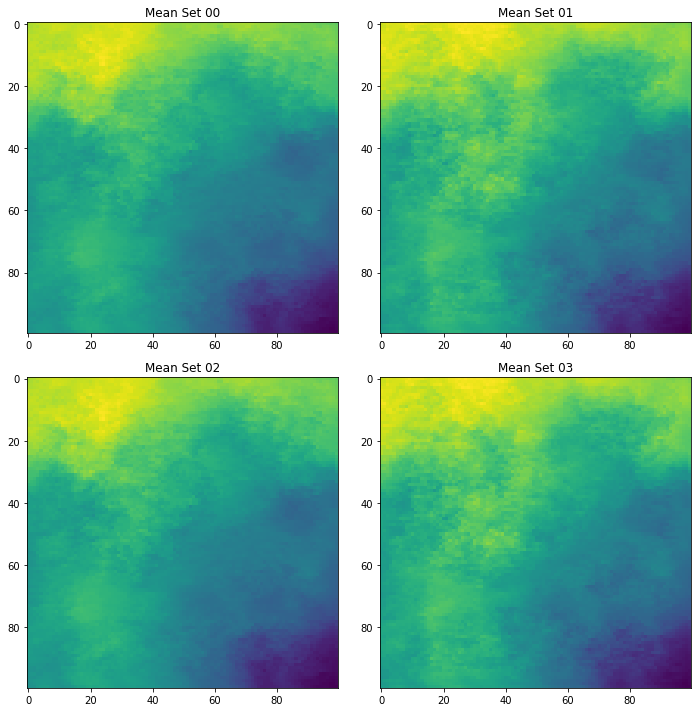

In [70]:
#Effect of the deesse parameter on the mean simulation for the test case 1
fig = plt.subplots(2,2,figsize=(10,10))
for i in range(len(all_results_2)):
    plt.subplot(2,2,i+1)
    plt.imshow(all_results_2[i].Mean[0])
    plt.title('Mean Set {}'.format(str(i).zfill(2)))

plt.tight_layout()
plt.show()

In [7]:
fig[0].savefig('mean_maps.png')

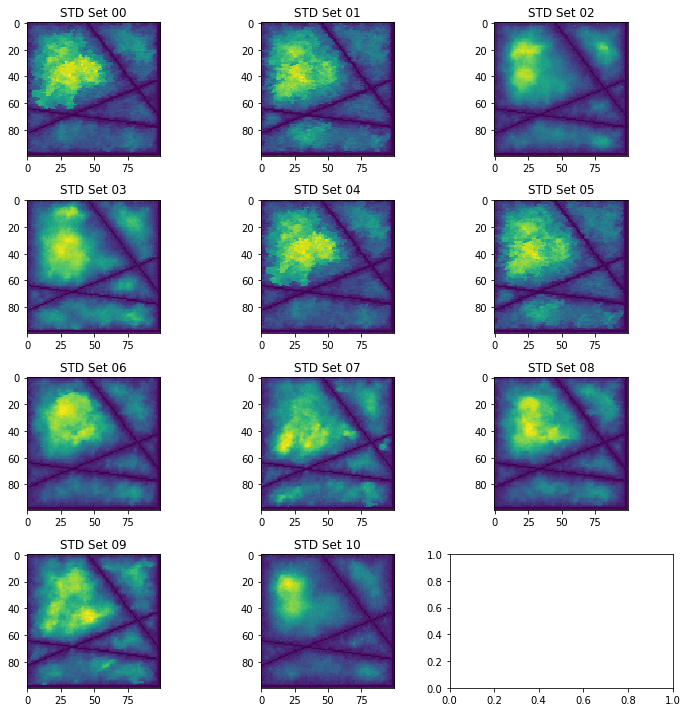

In [15]:
#Effect of the deesse parameter on the mean simulation for the test case 1
fig = plt.subplots(4,3,figsize=(10,10))
for i in range(len(all_results)):
    plt.subplot(4,3,i+1)
    plt.imshow(all_results[i].Sd[0])
    plt.title('STD Set {}'.format(str(i).zfill(2)))

plt.tight_layout()
plt.show()


In [14]:
fig[0].savefig('std_maps.png')

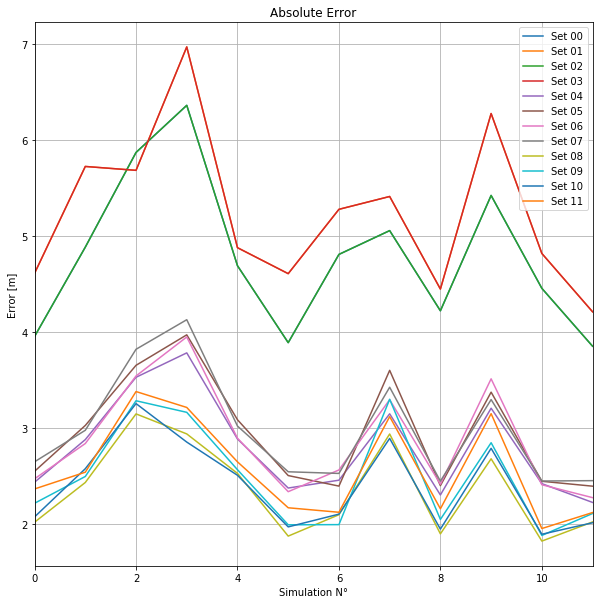

In [10]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results)):
    plt.plot(all_results[i].Abs_error.values,label = 'Set {}'.format(str(i).zfill(2)) )
plt.legend(loc=1)
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim([0,11])
plt.show()

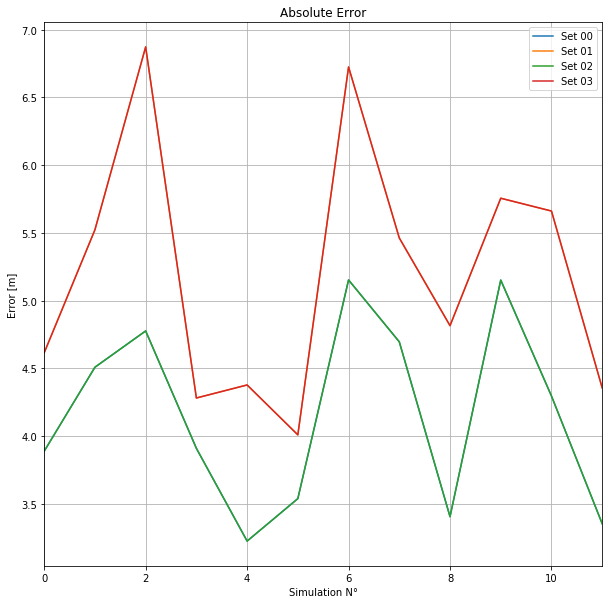

In [71]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results_2)):
    plt.plot(all_results_2[i].Abs_error.values,label = 'Set {}'.format(str(i).zfill(2)) )
plt.legend(loc=1)
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim([0,11])
plt.show()

In [17]:
fig.savefig('abs_error.png')

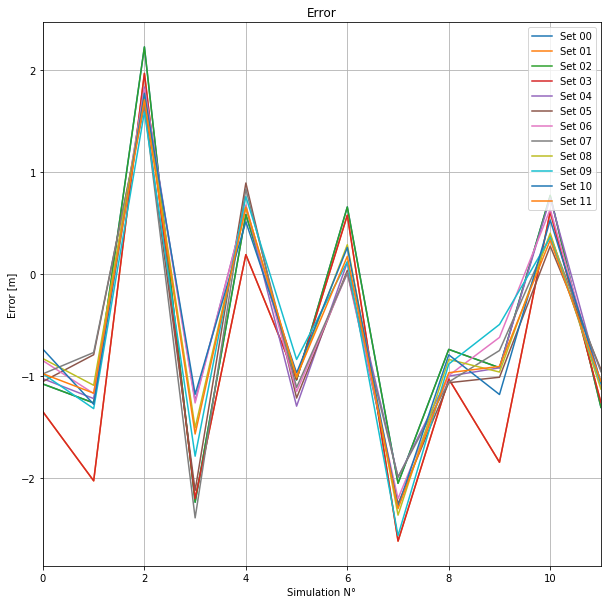

In [19]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results)):
    plt.plot(all_results[i].Error.values,label = 'Set {}'.format(str(i).zfill(2)) )
plt.legend(loc=1)
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim([0,11])
plt.show()

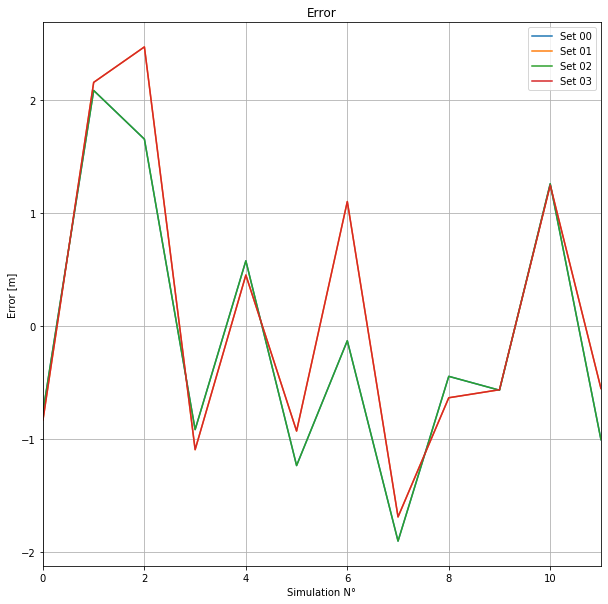

In [77]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results_2)):
    plt.plot(all_results_2[i].Error.values,label = 'Set {}'.format(str(i).zfill(2)) )
plt.legend(loc=1)
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim([0,11])
plt.show()

In [20]:
fig.savefig('error.png')

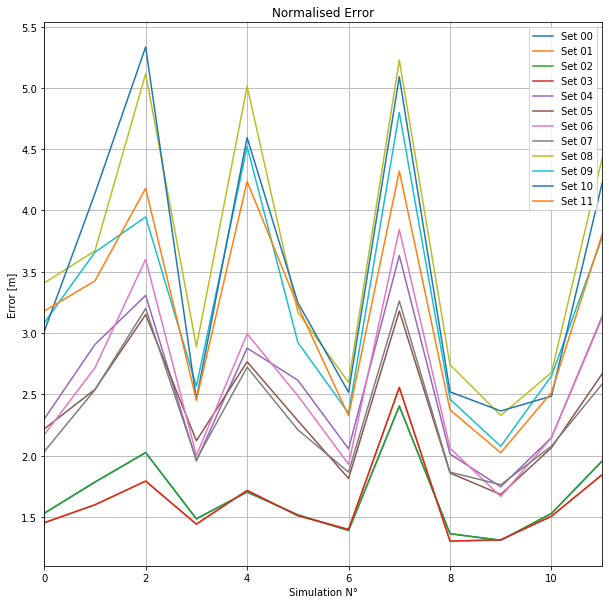

In [21]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results)):
    plt.plot(all_results[i].Norm_Error.values,label = 'Set {}'.format(str(i).zfill(2)) )
plt.legend(loc=1)
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
plt.grid()
plt.xlim([0,11])
plt.show()

In [22]:
fig.savefig('norm_error.png')

In [23]:
import seaborn as sns
#sns.set(color_codes=True)

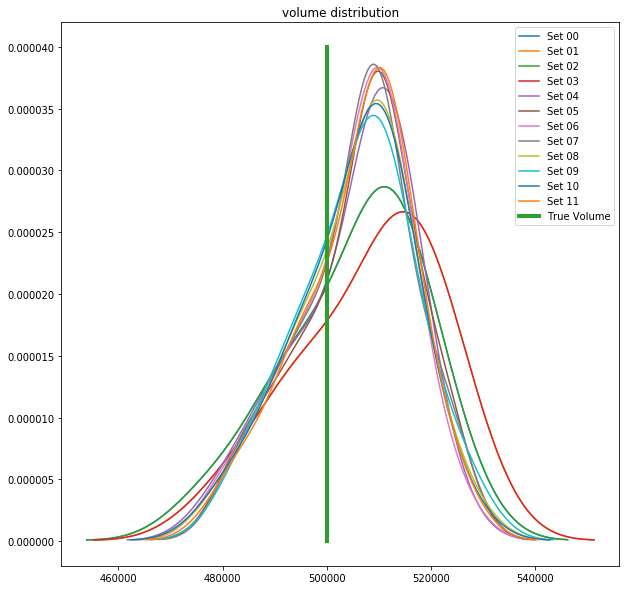

In [28]:
fig = plt.figure(figsize=(10,10))
for i in range(len(all_results)):
    volumes = []
    for simu in range(len(all_results[i].Volume.values)):
        volumes.append(np.mean(all_results[i].Volume.values[simu]))
    sns.distplot(volumes,hist=False, label = 'Set {}'.format(str(i).zfill(2)))
plt.plot([500000,500000],[0,0.00004],label='True Volume',linewidth=4)
plt.legend(loc=1)
plt.title('volume distribution')
plt.show()

In [29]:
fig.savefig('volume_distribution.png')

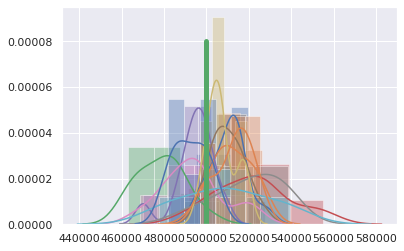

In [102]:
for i in range(12):
    sns.distplot(all_results[0].Volume.values[i])
plt.plot([500000,500000],[0,0.00008],label='True Volume',linewidth=5)


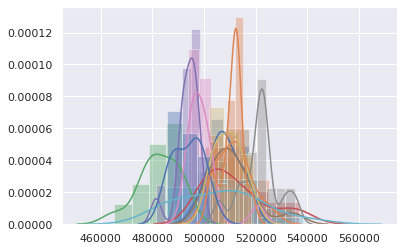

In [85]:
for i in range(12):
    sns.distplot(all_results[6].Volume.values[i])

Text(0.5, 0, 'Volume [m^2]')

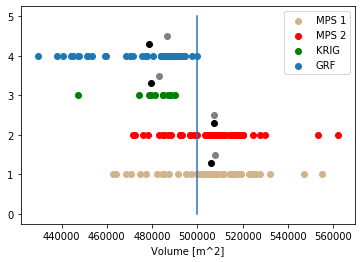

In [105]:
plt.scatter(vol_MPS1,np.ones(len(vol_MPS1)),color='tan')
plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1,color='red')
#plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1)
plt.scatter(vol_KRIG,np.ones(len(vol_KRIG))+2,color='green')
plt.scatter(vol_GRF,np.ones(len(vol_GRF))+3)
#plt.plot([real_vol, real_vol],[0,5],color = 'black')
plt.legend(['MPS 1', 'MPS 2', 'KRIG', 'GRF'])

plt.scatter(np.mean(vol_MPS1),1.3,color = 'black')
plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
#plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
plt.scatter(np.mean(vol_KRIG),3.3,color = 'black')
plt.scatter(np.mean(vol_GRF),4.3,color = 'black')

#plt.text(np.mean(vol_MPS1)+30000,1.3,'Mean')
#plt.text(np.mean(vol_MPS2)+30000,2.3,'Mean')
#plt.text(np.mean(vol_KRIG)+30000,3.3,'Mean')
#plt.text(np.mean(vol_GRF)+30000,4.3,'Mean')

plt.scatter(np.median(vol_MPS1),1.5,color = 'grey')
plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
#plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
plt.scatter(np.median(vol_KRIG),3.5,color = 'grey')
plt.scatter(np.median(vol_GRF),4.5,color = 'grey')

#plt.text(np.median(vol_MPS1)+30000,1.5,'Median')
#plt.text(np.median(vol_MPS2)+30000,2.5,'Median')
#plt.text(np.median(vol_KRIG)+30000,3.5,'Median')
#plt.text(np.median(vol_GRF)+30000,4.5,'Median')

ax = plt.gca()

#labels = [item.get_text() for item in ax.get_yticklabels()]
#labels[1] = 'Testing'
#ax.set_yticklabels(['','','MPS1','MPS2','KRIG','GRF'])

plt.plot([results_frame['Real Volume'][0]]*6, np.arange(0,6,1))
plt.xlabel('Volume [m^2]')

## Kriging output

In [94]:
all_output = []
real_vol = []
type_sim = ['KRIG']
for name in simulation_name_krig:
    
    with open(path_output_krig+name,'rb') as file:
        trueMNT, simu_sets, mask_box_ti, position = pickle.load(file)

    if np.all(simu_sets != None):
        indice_out = indice_calculationV(trueMNT, simu_sets, 'krig')
        
        all_output.append([name[:-12], type_sim[0]] +indice_out)
        
        
results_frame_k = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','Real Volume'])



/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:129: RuntimeWarning: invalid value encountered in true_divide


### OLD

Define the path of the data

In [2]:
path_output_krig = '../simulation_output_krig_set1/'
path_output_MPS  = '../simulation_output_set_trend_1/'

simulation_name_krig = os.listdir(path_output_krig)
simulation_name = os.listdir(path_output_MPS)
simulation_name_krig = sorted(simulation_name_krig)
simulation_name = sorted(simulation_name)

exec(open('../functions/03_indice_calculation_functions.py').read())


FileNotFoundError: [Errno 2] No such file or directory: '../simulation_output_krig_set1/'

In [3]:
simulation_name[0:3], simulation_name_krig[0:3]

(['realisation0_simu.pickle',
  'realisation1_simu.pickle',
  'realisation2_simu.pickle'],
 ['realisation0_krige.pickle',
  'realisation1_krige.pickle',
  'realisation2_krige.pickle'])

In [4]:
with open(path_output_MPS+simulation_name[4],'rb') as file:
    simus_sets = pickle.load(file)

trueMNT, trend_cut,[extr2,None,simGRF],mask[1], ref

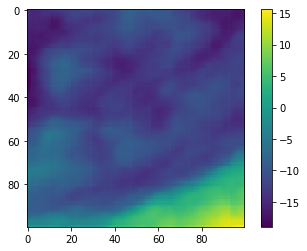

In [13]:
plt.imshow(simus_sets[0])
plt.colorbar()

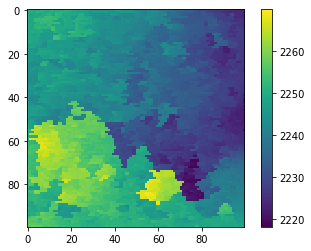

In [17]:
meanSS = np.add(simus_sets[1],simus_sets[2][0])
plt.imshow(meanSS[0])
plt.colorbar()

In [90]:
simus_sets[3]

array([2644, 2744,  791,  891])

In [91]:
a =[0,9]

In [92]:
np.all(a != None)

True

In [27]:
os.listdir('../')

['simulation_output_set_2',
 'Brouillon.ipynb',
 'simulation_trend',
 'generated_data',
 'real_data_cyprien',
 '.gitignore',
 '.ipynb_checkpoints',
 'simulation_output_krig_set1',
 'generated_data_test',
 'jupyter',
 'simulation_alexis',
 'old',
 'real_data',
 'simulation_output_set_trend_1',
 'data',
 'generated_data_old',
 '.git',
 'real_data_alexis',
 'simulation_output_set_1',
 'scripts',
 'functions',
 'README.md']

In [25]:
list_sets = ['set_1', 'set_2', 'set_trend_1']

In [20]:
all_output = []
real_vol = []
type_sim = ['MPS','GRF']
for name in simulation_name:
    
    with open(path_output_MPS+name,'rb') as file:
        trueMNT, trend_cut, simu_sets, mask_box_ti, position = pickle.load(file)
        
    trueMNT += trend_cut
    for i, simus in enumerate(simu_sets):        
        if np.all(simus != None):
            
            simus = np.add(trend_cut, simus)

            indice_out = indice_calculationA(trueMNT, simus, 'mps')
        
            all_output.append([name[:-12], type_sim[i]]+indice_out)
        
        
results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume','Real Volume'])



/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:83: RuntimeWarning: divide by zero encountered in true_divide
/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:83: RuntimeWarning: invalid value encountered in true_divide


In [95]:
%xmode plain

Exception reporting mode: Plain


In [21]:
results_frame.head()

,Sim_name,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume,Real Volume
0,realisation0,MPS,-1.137077,3.473365,1.640604,"[[2292.2376098632812, 2291.9398193359375, 2292...","[[0.6354961329287337, 0.7535558192487, 1.26170...","[529913.2072753906, 519624.0041503906, 502368....",500000.0
1,realisation1,MPS,-0.809821,3.038069,1.434308,"[[2524.2253621419272, 2523.9181315104165, 2524...","[[1.2062203048612512, 1.1950727581098646, 1.36...","[509462.5642089844, 508942.0622558594, 512164....",500000.0
2,realisation2,MPS,-0.735828,3.422478,2.055130,"[[2150.6896362304688, 2150.8915201822915, 2150...","[[0.7870159685356458, 0.8745312305467324, 0.70...","[504601.732421875, 505222.9479980469, 506461.5...",500000.0
3,realisation3,MPS,-1.571266,5.550606,1.632712,"[[2308.6089680989585, 2308.3300984700522, 2308...","[[0.29112290034454436, 0.5815122236624358, 0.4...","[498774.00048828125, 504441.255859375, 497956....",500000.0
4,realisation4,MPS,1.752105,4.832653,2.234671,"[[2251.0850219726562, 2250.7294108072915, 2249...","[[0.4963154647772063, 0.4197275623948463, 2.65...","[474217.08935546875, 488717.57470703125, 47255...",500000.0


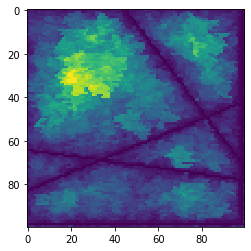

In [22]:
plt.imshow(results_frame.Sd[0])

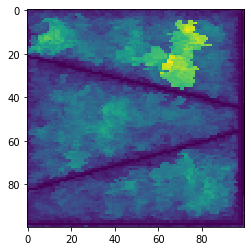

In [23]:
plt.imshow(results_frame.Sd[1])

In [15]:
dirName ='simu_reports'
numbers = []
try:
    # Create target Directory
    os.mkdir(dirName)
    print("Directory " , dirName ,  " Created ") 
    pdf_name = 'pdf_report_001.pdf'
except FileExistsError:
    print("Directory " , dirName ,  " already exists")
    pdf_name = os.listdir(dirName)
    for pdf_me in pdf_name:
        numbers.append(pdf_me[11:12])
    pdf_name = 'pdf_report_'+ str(int(max(numbers))+1).rjust(3, '0')+'.pdf' 


Directory  simu_reports  already exists


In [16]:
pdf_name

'pdf_report_010.pdf'

NameError: name 'results_frame_k' is not defined

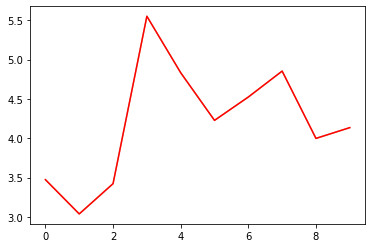

In [24]:
plt.plot(results_frame[results_frame['Type']=='MPS'].Abs_error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Abs_error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Abs_error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Abs_error.values)
plt.plot(np.arange(0,9,1),[0]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')


Text(0, 0.5, 'Error [m]')

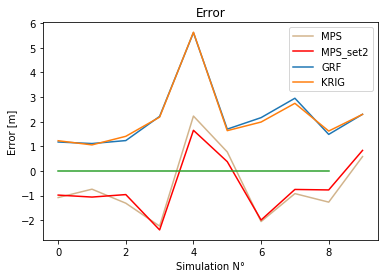

In [107]:
plt.plot(results_frame[results_frame['Type']=='MPS'].Error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Error.values)
plt.plot(np.arange(0,9,1),[0]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')

#plt.plot(np.ones(len(pts_0))*0,color='grey',ls='--')

Text(0, 0.5, 'Error [m]')

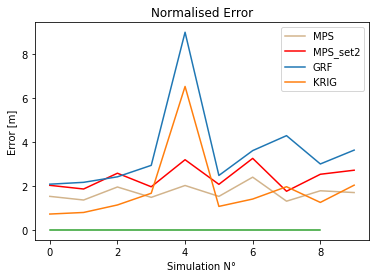

In [110]:
#etrange!!!!!!
plt.plot(results_frame[results_frame['Type']=='MPS'].Norm_Error.values,color='tan')
plt.plot(results_frame_2[results_frame_2['Type']=='MPS'].Norm_Error.values,color='red')
#plt.plot(results_frame[results_frame['Type']=='MPS2'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Norm_Error.values)
plt.plot(results_frame_k[results_frame_k['Type']=='KRIG'].Norm_Error.values)
plt.plot(np.arange(0,9,1),[0]*9)
plt.legend(['MPS','MPS_set2','GRF','KRIG'])
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*1,color='grey',ls='--')


In [104]:
vol_MPS1 = []
vol_MPS2 = []
vol_KRIG = []
vol_GRF = []


for i in range(int(results_frame.shape[0]/4)):
    vol_MPS1.extend(results_frame[results_frame['Type']=='MPS'].Volume.values[i][:])
    vol_MPS2.extend(results_frame_2[results_frame_2['Type']=='MPS'].Volume.values[i][:])

    #vol_MPS2.extend(results_frame[results_frame['Type']=='MPS2'].Volume.values[i])
    vol_GRF.extend(results_frame[results_frame['Type']=='GRF'].Volume.values[i])
vol_KRIG.extend(results_frame_k[results_frame_k['Type']=='KRIG'].Volume.values)

    

Text(0.5, 0, 'Volume [m^2]')

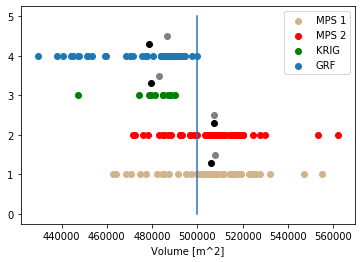

In [105]:
plt.scatter(vol_MPS1,np.ones(len(vol_MPS1)),color='tan')
plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1,color='red')
#plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1)
plt.scatter(vol_KRIG,np.ones(len(vol_KRIG))+2,color='green')
plt.scatter(vol_GRF,np.ones(len(vol_GRF))+3)
#plt.plot([real_vol, real_vol],[0,5],color = 'black')
plt.legend(['MPS 1', 'MPS 2', 'KRIG', 'GRF'])

plt.scatter(np.mean(vol_MPS1),1.3,color = 'black')
plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
#plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
plt.scatter(np.mean(vol_KRIG),3.3,color = 'black')
plt.scatter(np.mean(vol_GRF),4.3,color = 'black')

#plt.text(np.mean(vol_MPS1)+30000,1.3,'Mean')
#plt.text(np.mean(vol_MPS2)+30000,2.3,'Mean')
#plt.text(np.mean(vol_KRIG)+30000,3.3,'Mean')
#plt.text(np.mean(vol_GRF)+30000,4.3,'Mean')

plt.scatter(np.median(vol_MPS1),1.5,color = 'grey')
plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
#plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
plt.scatter(np.median(vol_KRIG),3.5,color = 'grey')
plt.scatter(np.median(vol_GRF),4.5,color = 'grey')

#plt.text(np.median(vol_MPS1)+30000,1.5,'Median')
#plt.text(np.median(vol_MPS2)+30000,2.5,'Median')
#plt.text(np.median(vol_KRIG)+30000,3.5,'Median')
#plt.text(np.median(vol_GRF)+30000,4.5,'Median')

ax = plt.gca()

#labels = [item.get_text() for item in ax.get_yticklabels()]
#labels[1] = 'Testing'
#ax.set_yticklabels(['','','MPS1','MPS2','KRIG','GRF'])

plt.plot([results_frame['Real Volume'][0]]*6, np.arange(0,6,1))
plt.xlabel('Volume [m^2]')